In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import cmdstanpy
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import shutil
from cmdstanpy import from_csv

# Windows-only: ensure rtools and TBB are on PATH
os.environ['PATH'] += r';C:\rtools42\usr\bin;C:\rtools42\x86_64-w64-mingw32.static.posix\bin'
cmdstan_path = cmdstanpy.cmdstan_path()
os.environ['PATH'] += f';{cmdstan_path}/stan/lib/stan_math/lib/tbb'

sys.path.append(os.path.abspath(".."))
from analogues import AnalogueSample, SelectionConfig, FilterConfig

c:\Users\Muhammad Abeer\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Stan Hierarchical Model

Two Stan models are defined below: one fit on the full dataset (for inference and LG prediction)
and one with a train/test split (for held-out validation). In this notebook the features used will be total stellar mass of pair, mass ratio, radial velocity and the g-r color.

In [ ]:
stan_code = """
data {
    int<lower=0> N;
    array[N] int<lower=1, upper=2> group;
    matrix[N, 5] X;          // standardized: g-r, v_r, sep, mass_ratios and total stellar masses
    vector[N] y;              // log M200c
    vector[5] x_lg;
}

parameters {
    real mu_alpha;
    real<lower=0> sigma_alpha;
    vector[5] mu_beta;
    
    vector[2] alpha_raw;
    vector<lower=0>[5] sigma_beta;
    matrix[2, 5] beta_raw;
    
    real<lower=1e-3> sigma;
}

transformed parameters {
    vector[2] alpha;
    matrix[2,5] beta;
    vector[N] eta;

    alpha = mu_alpha + sigma_alpha * alpha_raw;

    for (g in 1:2) {
        for (k in 1:5) {
            beta[g, k] = mu_beta[k] + sigma_beta[k] * beta_raw[g, k];
        }
    }

    for (n in 1:N) {
        eta[n] = alpha[group[n]] + dot_product(beta[group[n]], X[n]);
        // eta[n] = fmin(fmax(eta[n], -20), 20);
    }
}

model {
    alpha_raw ~ normal(0, 1);
    to_vector(beta_raw) ~ normal(0, 1);
    
    mu_alpha ~ normal(12.6, 0.2);     // (3.17+-0.57) x10^12 ~LogM ~ 12.5 van der Marel et al. (2012)

    // Blue-blue peaks at 12-12.5, red-red extends to 13.8 (baryon efficiency plot from EDA)
    // Expecting ~0.3-0.5 dex difference between groups
    sigma_alpha ~ normal(0.15, 0.1);  // The blue-blue and red-red intercepts are expected to differ by at most 0.2-0.3 dex based on the baryon efficiency plot from EDA, with the prior centered to reflect this modest group-level variation.
    
    // The magnitude (0.2 dex per unit color) is chosen to represent a modest, non-dominant effect consistent with observed scatter.
    mu_beta[1] ~ normal(0.2, 0.3);   // g-r coefficient: positive — redder = more massive. 

    // Using weakly informed prior centered at zero to allow the data to determine both the direction and magnitude of the effect.
    mu_beta[2] ~ normal(0.0, 0.2);   // v_r coefficient no strong prior K statistics show some relevance but didn't find any literature conirming this

    mu_beta[3] ~ normal(0.0, 0.2);   // seperation coefficient: No strong theoretical expectation that pair separation directly determines halo mass

    mu_beta[4] ~ normal(0.0, 0.2);   // mass ratio coefficient: weak prior

    // A moderately positive prior centered around 0.3 is adopted, allowing for uncertainty while avoiding unrealistically steep scaling.
    mu_beta[5] ~ normal(0.3, 0.2);   // total stellar mass coefficient: Total stellar mass is expected to correlate positively with halo mass

    // group variation in coefficients
    // Does not allow extreme differences but only small ones which makes sense from EDA
    sigma_beta ~ exponential(10);    // An exponential prior with rate 10 (mean = 0.1) shows small group-level deviations
    // Residual scatter truncated to only be positive
    // From Moster et al (2013)
    sigma ~ normal(0.3, 0.1); // obs scatter is between 0.15 intrinsic physical scatter from the above resource. We choose slightly higher value
    
    for (n in 1:N) {
        y[n] ~ normal(eta[n], sigma);
    }
       
}

generated quantities {
    vector[N] y_rep;
    vector[N] log_lik; 
    vector[N] eta_rep;
    real y_lg_bb;
    real y_lg_rr; 

    // LG predictions 
    y_lg_bb = normal_rng(alpha[1] + dot_product(beta[1], x_lg), sigma);
    y_lg_rr = normal_rng(alpha[2] + dot_product(beta[2], x_lg), sigma);

    for (n in 1:N) {
        y_rep[n] = normal_rng(
            alpha[group[n]] + dot_product(beta[group[n]], X[n]),
            sigma
        );
        log_lik[n] = normal_lpdf(y[n] | 
            alpha[group[n]] + dot_product(beta[group[n]], X[n]),
            sigma
        );  
    }


    for (n in 1:N) {
        eta_rep[n] = alpha[group[n]] + dot_product(beta[group[n]], X[n]);
    }
}
"""

In [3]:
stan_code_2 = """
data {
    int<lower=0> N_train;
    int<lower=0> N_test;
    array[N_train] int<lower=1, upper=2> group_train;
    array[N_test] int<lower=1, upper=2> group_test;
    matrix[N_train, 5] X_train;
    matrix[N_test, 5] X_test;
    vector[N_train] y_train;
    vector[5] x_lg;
}

parameters {
    real mu_alpha;
    real<lower=0> sigma_alpha;
    vector[5] mu_beta;
    vector<lower=0>[5] sigma_beta;
    
    vector[2] alpha_raw;
    matrix[2, 5] beta_raw;
    
    real<lower=1e-3> sigma;
}

transformed parameters {
    vector[2] alpha;
    matrix[2,5] beta;

    alpha = mu_alpha + sigma_alpha * alpha_raw;

    for (g in 1:2) {
        for (k in 1:5) {
            beta[g, k] = mu_beta[k] + sigma_beta[k] * beta_raw[g, k];
        }
    }
}

model {
    alpha_raw ~ normal(0, 1);
    to_vector(beta_raw) ~ normal(0, 1);
    
    mu_alpha ~ normal(12.6, 0.2);
    sigma_alpha ~ exponential(2);

    mu_beta[1] ~ normal(0.2, 0.3);
    mu_beta[2] ~ normal(0.0, 0.2);
    mu_beta[3] ~ normal(0.0, 0.2);
    mu_beta[4] ~ normal(0.0, 0.2);
    mu_beta[5] ~ normal(0.3, 0.2);

    sigma_beta ~ exponential(10);
    sigma ~ normal(0.3, 0.1);
    
    for (n in 1:N_train)
        y_train[n] ~ normal(
            alpha[group_train[n]] + dot_product(beta[group_train[n]], X_train[n]),
            sigma
        );
}

generated quantities {
    vector[N_train] y_rep_train;
    vector[N_train] log_lik;
    vector[N_test] y_rep_test;
    real y_lg_bb;
    real y_lg_rr;

    for (n in 1:N_train) {
        y_rep_train[n] = normal_rng(
            alpha[group_train[n]] + dot_product(beta[group_train[n]], X_train[n]),
            sigma
        );
        log_lik[n] = normal_lpdf(y_train[n] |
            alpha[group_train[n]] + dot_product(beta[group_train[n]], X_train[n]),
            sigma
        );
    }
    
    for (n in 1:N_test) {
        y_rep_test[n] = normal_rng(
            alpha[group_test[n]] + dot_product(beta[group_test[n]], X_test[n]),
            sigma
        );
    }

    y_lg_bb = normal_rng(alpha[1] + dot_product(beta[1], x_lg), sigma);
    y_lg_rr = normal_rng(alpha[2] + dot_product(beta[2], x_lg), sigma);
}
"""

## 1. Build Analogue Sample

The `AnalogueSample` class replaces the old manual pipeline of separate calls to
`load_header_constants`, `select_central_plus_largest_satellite_by_stellar_mass`,
`find_pairs_periodic`, and the individual isolation/velocity filter functions.
All configuration is now passed declaratively via `SelectionConfig` and `FilterConfig`.

In [4]:
base_path = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")  

selection_config = SelectionConfig(
    m_stellar_min=2e10,    # M_sun
    m_stellar_max=5e11,    # M_sun
    r_min=500.0,           # kpc
    r_max=1000.0,          # kpc
    blue_threshold_gr=0.65
)

filter_config = FilterConfig(
    vt_min=0,              # km/s
    vt_max=300,            # km/s
    vr_min=-400,           # km/s
    vr_max=0,              # km/s
    v_tot_min=0,           # km/s
    v_tot_max=500,         # km/s
    third_massive_factor=1.5,
    density_radius=2000,   # kpc 
    intruder_factor=0.5,
)

analogue_sample = AnalogueSample(
    base_path=base_path,
    selection_config=selection_config,
    filter_config=filter_config,
    snap=99,
    verbose=True,
)


[DIAGNOSTIC] Simulation Header Constants
╒════════════╤═══════════╤═══════════════╕
│ Parameter  │ Value     │ Units         │
├────────────┼───────────┼───────────────┤
│ Hubble (h) │ 0.6774    │ dimensionless │
├────────────┼───────────┼───────────────┤
│ Box Side   │ 302627.69 │ kpc           │
╘════════════╧═══════════╧═══════════════╛

[DIAGNOSTIC] Sample Selection
╒═════════════════════════════════════════╤══════════╤═════════════════╕
│ Selection Step                          │    Count │ Yield           │
╞═════════════════════════════════════════╪══════════╪═════════════════╡
│ Total Subhalos in Catalog               │ 14485709 │ 100.0%          │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Passed Quality Flags (SubhaloFlag==1)   │  1902558 │ 13.1%           │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Inside Stellar Mass Window              │    60562 │ 3.2% of good    │
├─────────────────────────────────────────

## 2. Extract Pairs and Build Feature Matrix

All pair properties are now stored in `PairSet`. Photometry is accessed via
`sample.g_band` / `sample.r_band` (pre-extracted in `Sample`), so the manual
`sub['SubhaloStellarPhotometrics'][sample.keep_idx]` indexing is no longer needed.
Mixed (blue-red) pairs are dropped; only pure blue-blue and red-red pairs are retained.

In [ ]:
pairs = analogue_sample.pairs

sample = analogue_sample._sample 

i = pairs.i
j = pairs.j

# Keep only pure pairs (blue-blue or red-red)
keep_pure = pairs.is_blue_blue | pairs.is_red_red

i_f = i[keep_pure]
j_f = j[keep_pure]

# g-r color per member (already stored in Sample)
g_r_1 = sample.g_band[i_f] - sample.r_band[i_f]
g_r_2 = sample.g_band[j_f] - sample.r_band[j_f]

bb_f = (g_r_1 < selection_config.blue_threshold_gr) & (g_r_2 < selection_config.blue_threshold_gr)
rr_f = (g_r_1 >= selection_config.blue_threshold_gr) & (g_r_2 >= selection_config.blue_threshold_gr)

# Stellar masses (M_sun)
h = analogue_sample._selection_config.hubble_param
Mi_star = sample.m_stellar[i_f]
Mj_star = sample.m_stellar[j_f]

# Derived features
g_r_mean      = (g_r_1 + g_r_2) / 2
mass_ratio    = np.abs(np.log10(Mi_star / Mj_star))
log_Mtot_star = np.log10(Mi_star + Mj_star)
vr_f          = pairs.vr[keep_pure]
vt_f          = pairs.vt[keep_pure]
sep_f         = pairs.separation[keep_pure]

features = np.column_stack([g_r_mean, vr_f, sep_f, mass_ratio, log_Mtot_star])

# Target: mean log M200c of the pair (M_sun)
log_m200c = 0.5 * (
    np.log10(sample.m200c[i_f]) +
    np.log10(sample.m200c[j_f])
)

# Group labels: 1 = blue-blue, 2 = red-red
group = np.where(bb_f, 1, 2).astype(int)

print(f'Pure pairs: {keep_pure.sum()}')
print(f'  Blue-blue: {bb_f.sum()}')
print(f'  Red-red:   {rr_f.sum()}')
print(f'log_Mtot_star range: {log_Mtot_star.min():.2f} to {log_Mtot_star.max():.2f}')
print(f'mass_ratio range:    {mass_ratio.min():.2f} to {mass_ratio.max():.2f}')
print(f'log M200c range:     {log_m200c.min():.2f} to {log_m200c.max():.2f}')

Pure pairs: 1072
  Blue-blue: 165
  Red-red:   907
log_Mtot_star range: 10.63 to 11.81
mass_ratio range:    0.00 to 1.19
log M200c range:     11.69 to 13.87


## 3. Standardise Features and Encode LG Observables

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_clipped = np.clip(X_scaled, -3, 3)

feat_mean = scaler.mean_
feat_std  = scaler.scale_

print('Column means (should be ~0):', X_scaled.mean(axis=0).round(4))
print('Column stds  (should be ~1):', X_scaled.std(axis=0).round(4))
print('Max |z| per column:', np.max(np.abs(X_scaled), axis=0).round(2))

# Real Local Group observables
lg_obs_raw = np.array([
    0.59,                             # g-r mean (MW~0.53, M31~0.63)
    -109.3,                           # v_r [km/s]
    765.0,                            # separation [kpc]
    np.abs(np.log10(6e10 / 1e11)),    # |log mass ratio|
    np.log10(6e10 + 1e11),            # log total stellar mass
])
lg_obs_scaled = (lg_obs_raw - feat_mean) / feat_std

print(f'\nLG obs max |z|: {np.max(np.abs(lg_obs_scaled)):.3f}  (should be < 3)')
assert np.all(np.isfinite(X_scaled)), 'Non-finite values in X_scaled'
assert np.all(np.isfinite(log_m200c)), 'Non-finite values in log_m200c'

Column means (should be ~0): [ 0.  0. -0. -0. -0.]
Column stds  (should be ~1): [1. 1. 1. 1. 1.]
Max |z| per column: [4.6  2.55 1.73 3.43 2.61]

LG obs max |z|: 0.985  (should be < 3)


## 4. Compile Stan Models

In [7]:
with open('hierarchical_model.stan', 'w') as f:
    f.write(stan_code)
model = cmdstanpy.CmdStanModel(stan_file='hierarchical_model.stan')

with open('hierarchical_model_2.stan', 'w') as f:
    f.write(stan_code_2)
model_2 = cmdstanpy.CmdStanModel(stan_file='hierarchical_model_2.stan')

print('Both models compiled successfully!')

14:43:32 - cmdstanpy - INFO - compiling stan file C:\Users\MUHAMM~1\AppData\Local\Temp\tmpjp7eu6po\tmpbr2y2xh2.stan to exe file D:\Data science project\hierarchical_model.exe
14:44:15 - cmdstanpy - INFO - compiled model executable: D:\Data science project\hierarchical_model.exe
14:44:16 - cmdstanpy - INFO - compiling stan file C:\Users\MUHAMM~1\AppData\Local\Temp\tmpvw905olf\tmpm3zukal1.stan to exe file D:\Data science project\hierarchical_model_2.exe
14:44:55 - cmdstanpy - INFO - compiled model executable: D:\Data science project\hierarchical_model_2.exe


Both models compiled successfully!


## Prior Predictive Checks

Important that likelihood was commented out in the stan model to ensure that priors chosen are reasonable.

In [8]:
# # Stan data dictionary
# stan_data = {
#     "N": int(X_scaled.shape[0]),
#     "group": group.tolist(),
#     "X": X_scaled.tolist(),
#     "y": log_m200c.tolist()
# }

# # Sample from prior only (likelihood commented out)
# fit_prior = model.sample(
#     data=stan_data,
#     chains=4,
#     iter_sampling=500,
#     iter_warmup=500,
#     show_progress=True
# )

# print(fit_prior.summary())


In [9]:
# import arviz as az
# import matplotlib.pyplot as plt

# idata_prior = az.from_cmdstanpy(fit_prior)

# # Extract prior predictive samples
# y_prior = fit_prior.stan_variable("y_rep")

# fig, ax = plt.subplots(figsize=(9, 5))

# # Prior predictive distribution
# ax.hist(y_prior.flatten(), bins=50, density=True,
#         color='blue', alpha=0.4, label='Prior predictive')

# # Actual data distribution
# ax.hist(log_m200c, bins=30, density=True,
#         color='red', alpha=0.4, label='Actual data')

# # Reference lines
# ax.axvline(12.5, color='black', linestyle='--', 
#            linewidth=2, label='Real LG ~12.5')
# ax.axvline(log_m200c.mean(), color='red', linestyle='-',
#            linewidth=1, label=f'Data mean={log_m200c.mean():.2f}')

# ax.set_xlabel('log M200c [Msun]')
# ax.set_ylabel('Density')
# ax.set_title('Prior Predictive Check')
# ax.legend()
# ax.set_xlim(10, 15)
# plt.tight_layout()
# plt.show()

# print(f"Prior predictive mean: {y_prior.mean():.2f}")
# print(f"Prior predictive std: {y_prior.std():.2f}")
# print(f"Prior predictive 2.5%: {np.percentile(y_prior, 2.5):.2f}")
# print(f"Prior predictive 97.5%: {np.percentile(y_prior, 97.5):.2f}")
# print(f"\nActual data mean: {log_m200c.mean():.2f}")
# print(f"Actual data std: {log_m200c.std():.2f}")
# print("Data range:", log_m200c.min(), log_m200c.max())
# print("Prior range:", y_prior.min(), y_prior.max())

## 5. Full-Data Posterior Fit

In [10]:
stan_data = {
    'N':     int(X_scaled.shape[0]),
    'group': group.tolist(),
    'X':     X_scaled.tolist(),
    'y':     log_m200c.tolist(),
    'x_lg':  lg_obs_scaled.tolist(),
}

# fit = model.sample(
#     data=stan_data,
#     chains=4,
#     parallel_chains=4,
#     iter_sampling=1000,
#     iter_warmup=2000,
#     adapt_delta=0.999,
#     max_treedepth=15,
#     show_progress=True,
# )

# eta_samples = fit.stan_variable('eta')
# print('Any inf/nan in posterior eta:', np.any(~np.isfinite(eta_samples)))

os.makedirs("saved_fits/model_1", exist_ok=True)

if os.path.exists("saved_fits/model_1") and any(
    f.endswith(".csv") for f in os.listdir("saved_fits/model_1")
):
    print("Loading saved model 1...")
    fit = from_csv("saved_fits/model_1/")
    print("Loaded!")
else:
    print("Fitting model 1...")
    fit = model.sample(
        data=stan_data,
        chains=4,
        parallel_chains=4,
        iter_sampling=1000,
        iter_warmup=2000,
        adapt_delta=0.999,
        max_treedepth=15,
        show_progress=True,
    )
    for f in fit.runset.csv_files:
        shutil.copy(f, "saved_fits/model_1/")
    print("Fitted and saved!")

eta_samples = fit.stan_variable('eta')
print('Any inf/nan in posterior eta:', np.any(~np.isfinite(eta_samples)))

Loading saved model 1...
Loaded!
Any inf/nan in posterior eta: False


## 6. Convergence Diagnostics

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Max R-hat: 1.0052  (should be < 1.01)
Min ESS:   1075  (should be > 400)
All R-hats < 1.01 — good convergence ✓


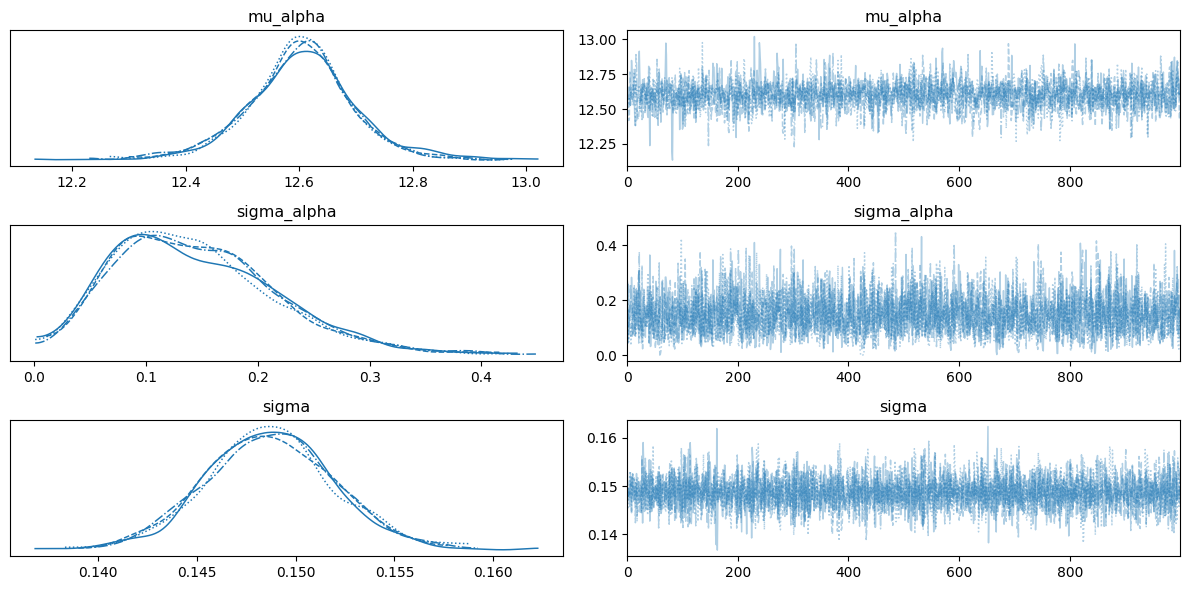

In [11]:
print(fit.diagnose())

summary = fit.summary()
print(f"Max R-hat: {summary['R_hat'].max():.4f}  (should be < 1.01)")
print(f"Min ESS:   {summary['ESS_bulk'].min():.0f}  (should be > 400)")

bad = summary[summary['R_hat'] > 1.01]
if len(bad):
    print('WARNING — Parameters with R-hat > 1.01:')
    print(bad[['R_hat', 'ESS_bulk']])
else:
    print('All R-hats < 1.01 — good convergence ✓')

idata = az.from_cmdstanpy(
    fit,
    posterior_predictive='y_rep',
    log_likelihood='log_lik',
    observed_data={'y': log_m200c},
)
az.plot_trace(idata, var_names=['mu_alpha', 'sigma_alpha', 'sigma'])
plt.tight_layout()
plt.show()

In [12]:
print("Model 1 diagnostics")
print(fit.diagnose())

summary_1 = fit.summary()
print(summary_1.sort_values('R_hat', ascending=False).head(10)[['R_hat', 'ESS_bulk']])

Model 1 diagnostics
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

                 R_hat  ESS_bulk
beta_raw[1,1]  1.00521   2954.23
alpha_raw[2]   1.00485   2482.35
mu_alpha       1.00380   2392.39
eta[771]       1.00370   4024.29
eta_rep[771]   1.00370   4024.29
mu_beta[4]     1.00344   1712.48
eta_rep[541]   1.00297   3741.19
eta[541]       1.00297   3741.19
eta[245]       1.00293   4243.41
eta_rep[245]   1.00293   4243.41


## 7. Posterior Predictive Check

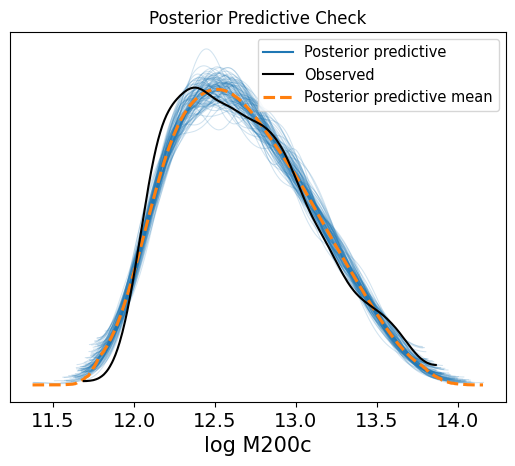

In [13]:
az.plot_ppc(idata, data_pairs={'y': 'y_rep'}, num_pp_samples=100)
plt.title('Posterior Predictive Check')
plt.xlabel('log M200c')
plt.show()

## 8. In-Sample Fit Quality

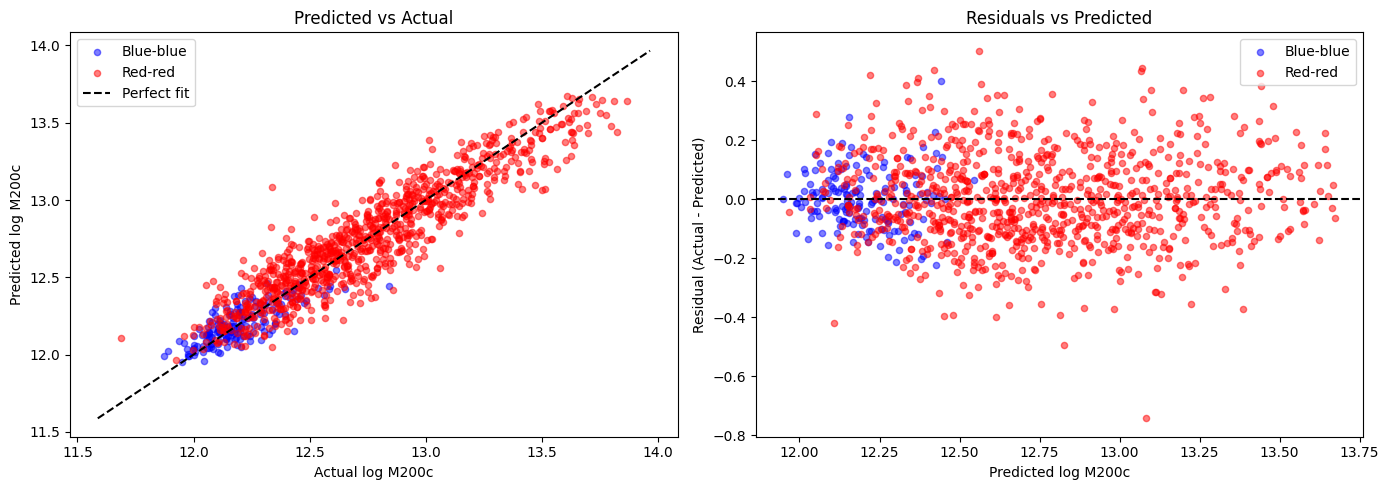

=== Overall ===
R²:   0.880
RMSE: 0.148 dex

Blue-blue R²: 0.602
Red-red R²:   0.852


In [14]:
y_rep = fit.stan_variable('y_rep')
y_pred_mean = y_rep.mean(axis=0)
residuals   = log_m200c - y_pred_mean

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(log_m200c[group==1], y_pred_mean[group==1], alpha=0.5, color='blue', label='Blue-blue', s=20)
ax.scatter(log_m200c[group==2], y_pred_mean[group==2], alpha=0.5, color='red',  label='Red-red',   s=20)
lims = [log_m200c.min()-0.1, log_m200c.max()+0.1]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual log M200c'); ax.set_ylabel('Predicted log M200c')
ax.set_title('Predicted vs Actual'); ax.legend()

ax = axes[1]
ax.scatter(y_pred_mean[group==1], residuals[group==1], alpha=0.5, color='blue', label='Blue-blue', s=20)
ax.scatter(y_pred_mean[group==2], residuals[group==2], alpha=0.5, color='red',  label='Red-red',   s=20)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted log M200c'); ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title('Residuals vs Predicted'); ax.legend()

plt.tight_layout(); plt.show()

print('=== Overall ===')
print(f"R²:   {r2_score(log_m200c, y_pred_mean):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(log_m200c, y_pred_mean)):.3f} dex")
bb = group==1; rr = group==2
print(f"\nBlue-blue R²: {r2_score(log_m200c[bb], y_pred_mean[bb]):.3f}")
print(f"Red-red R²:   {r2_score(log_m200c[rr], y_pred_mean[rr]):.3f}")

## 9. Posterior Coefficients by Group

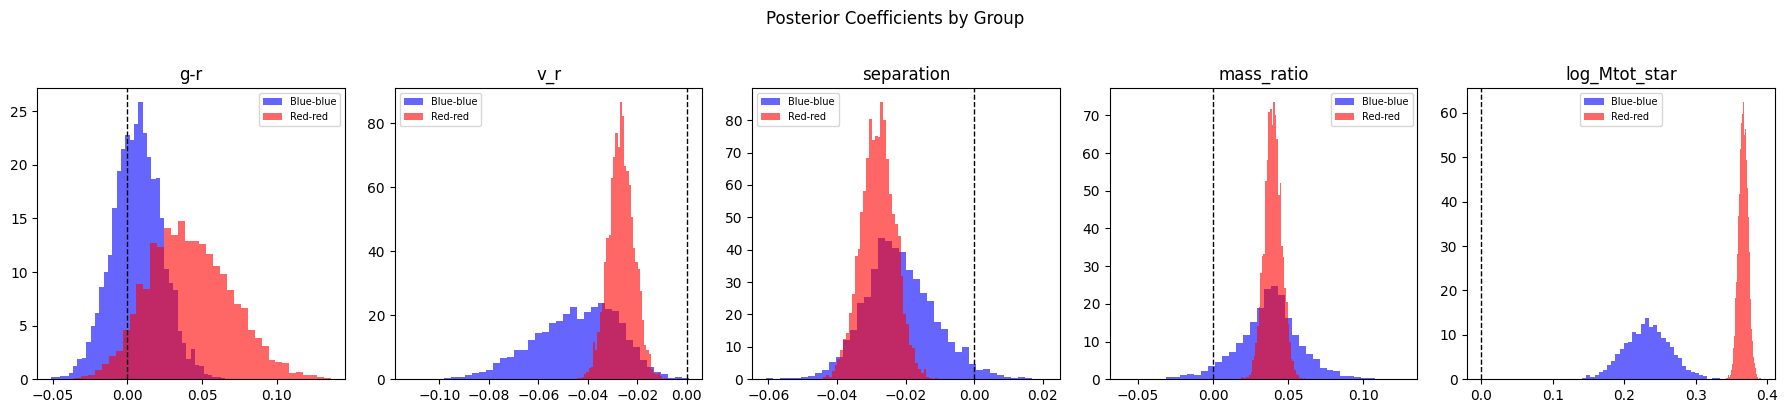

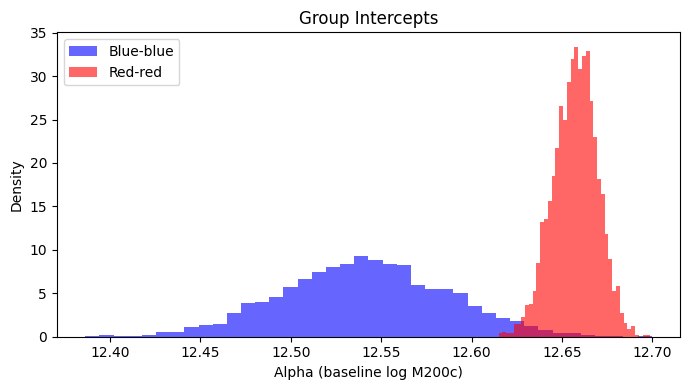

Blue-blue intercept: 12.541 ± 0.046
Red-red intercept:   12.657 ± 0.012
Difference (rr-bb):  0.117 ± 0.048 dex


In [15]:
feature_names = ['g-r', 'v_r', 'separation', 'mass_ratio', 'log_Mtot_star']
beta_samples  = fit.stan_variable('beta')  # (n_samples, 2, 5)
alpha_samples = fit.stan_variable('alpha') # (n_samples, 2)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for k, (ax, name) in enumerate(zip(axes, feature_names)):
    ax.hist(beta_samples[:, 0, k], bins=40, alpha=0.6, color='blue', label='Blue-blue', density=True)
    ax.hist(beta_samples[:, 1, k], bins=40, alpha=0.6, color='red',  label='Red-red',   density=True)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(name); ax.legend(fontsize=7)
plt.suptitle('Posterior Coefficients by Group', y=1.02)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(alpha_samples[:, 0], bins=40, alpha=0.6, color='blue', label='Blue-blue', density=True)
ax.hist(alpha_samples[:, 1], bins=40, alpha=0.6, color='red',  label='Red-red',   density=True)
ax.set_xlabel('Alpha (baseline log M200c)'); ax.set_ylabel('Density')
ax.set_title('Group Intercepts'); ax.legend()
plt.tight_layout(); plt.show()

print(f"Blue-blue intercept: {alpha_samples[:,0].mean():.3f} ± {alpha_samples[:,0].std():.3f}")
print(f"Red-red intercept:   {alpha_samples[:,1].mean():.3f} ± {alpha_samples[:,1].std():.3f}")
diff = alpha_samples[:,1] - alpha_samples[:,0]
print(f"Difference (rr-bb):  {diff.mean():.3f} ± {diff.std():.3f} dex")

What is interesting in the above plot is conditioning upon g-r, radial velocity, stellar mass, mass ratio and seperation bb and rr have different posterior distributions. Which shows that pair color classification provides some information about halo mass as well as they have hardly any overlap.

## 10. LOO-CV Model Comparison

In [16]:
loo = az.loo(idata)
print(loo)

Computed from 4000 posterior samples and 1072 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   518.19    26.96
p_loo       11.00        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1072  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



## 11. Local Group Halo Mass Posterior

Using the real LG observables (standardized above), we read out `y_lg_bb` and `y_lg_rr`
from the generated quantities block.

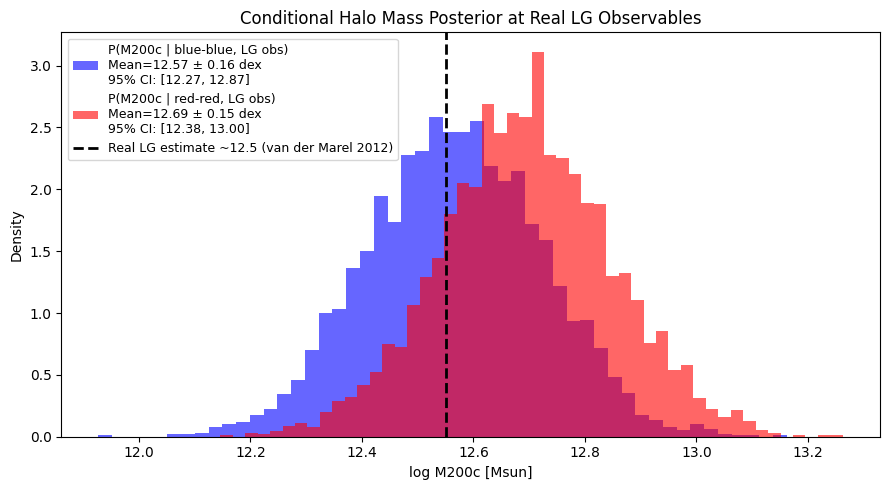

=== Key Result ===
P(log M200c | blue-blue, LG obs) = 12.567 ± 0.156
95% CI: [12.267, 12.865]

P(log M200c | red-red, LG obs)   = 12.694 ± 0.154
95% CI: [12.384, 12.995]

Difference (rr - bb): 0.126 ± 0.224 dex
P(M200c_rr > M200c_bb | LG obs): 0.716


In [17]:
y_lg_bb = fit.stan_variable("y_lg_bb")
y_lg_rr = fit.stan_variable("y_lg_rr")

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(y_lg_bb, bins=50, density=True, alpha=0.6, color='blue',
        label=f'P(M200c | blue-blue, LG obs)\n'
              f'Mean={y_lg_bb.mean():.2f} ± {y_lg_bb.std():.2f} dex\n'
              f'95% CI: [{np.percentile(y_lg_bb,2.5):.2f}, {np.percentile(y_lg_bb,97.5):.2f}]')

ax.hist(y_lg_rr, bins=50, density=True, alpha=0.6, color='red',
        label=f'P(M200c | red-red, LG obs)\n'
              f'Mean={y_lg_rr.mean():.2f} ± {y_lg_rr.std():.2f} dex\n'
              f'95% CI: [{np.percentile(y_lg_rr,2.5):.2f}, {np.percentile(y_lg_rr,97.5):.2f}]')

ax.axvline(12.55, color='black', linestyle='--', linewidth=2,
           label='Real LG estimate ~12.5 (van der Marel 2012)')

ax.set_xlabel('log M200c [Msun]')
ax.set_ylabel('Density')
ax.set_title('Conditional Halo Mass Posterior at Real LG Observables')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Key numbers
print("=== Key Result ===")
print(f"P(log M200c | blue-blue, LG obs) = {y_lg_bb.mean():.3f} ± {y_lg_bb.std():.3f}")
print(f"95% CI: [{np.percentile(y_lg_bb,2.5):.3f}, {np.percentile(y_lg_bb,97.5):.3f}]")
print(f"\nP(log M200c | red-red, LG obs)   = {y_lg_rr.mean():.3f} ± {y_lg_rr.std():.3f}")
print(f"95% CI: [{np.percentile(y_lg_rr,2.5):.3f}, {np.percentile(y_lg_rr,97.5):.3f}]")
print(f"\nDifference (rr - bb): {(y_lg_rr - y_lg_bb).mean():.3f} ± {(y_lg_rr - y_lg_bb).std():.3f} dex")
print(f"P(M200c_rr > M200c_bb | LG obs): {(y_lg_rr > y_lg_bb).mean():.3f}")

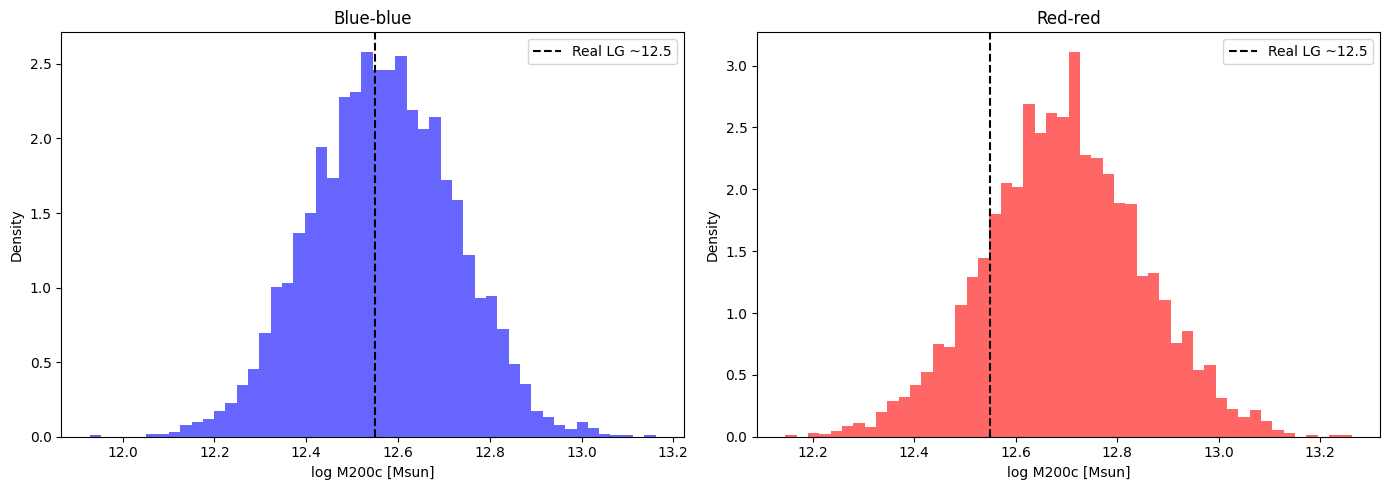

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_lg_bb, bins=50, density=True, color='blue', alpha=0.6)
axes[0].set_title('Blue-blue')
axes[0].set_xlabel('log M200c [Msun]')
axes[0].set_ylabel('Density')
axes[0].axvline(12.55, color='black', linestyle='--', label='Real LG ~12.5')
axes[0].legend()

axes[1].hist(y_lg_rr, bins=50, density=True, color='red', alpha=0.6)
axes[1].set_title('Red-red')
axes[1].set_xlabel('log M200c [Msun]')
axes[1].set_ylabel('Density')
axes[1].axvline(12.55, color='black', linestyle='--', label='Real LG ~12.5')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Train / Test Validation

In [19]:
train_idx, test_idx = train_test_split(
    np.arange(len(log_m200c)),
    test_size=0.2,
    random_state=42,
    stratify=group,
)

X_train, y_train, g_train = X_scaled[train_idx], log_m200c[train_idx], group[train_idx]
X_test,  y_test,  g_test  = X_scaled[test_idx],  log_m200c[test_idx],  group[test_idx]

print(f'Train: {len(train_idx)} pairs  (bb={( g_train==1).sum()}, rr={(g_train==2).sum()})')
print(f'Test:  {len(test_idx)}  pairs  (bb={(g_test==1).sum()},  rr={(g_test==2).sum()})')

stan_data_split = {
    'N_train':     int(len(train_idx)),
    'N_test':      int(len(test_idx)),
    'group_train': g_train.tolist(),
    'group_test':  g_test.tolist(),
    'X_train':     X_train.tolist(),
    'X_test':      X_test.tolist(),
    'y_train':     y_train.tolist(),
    'x_lg':        lg_obs_scaled.tolist(),
}

# fit_2 = model_2.sample(
#     data=stan_data_split,
#     chains=4,
#     parallel_chains=4,
#     iter_sampling=1000,
#     iter_warmup=2000,
#     adapt_delta=0.999,
#     max_treedepth=15,
#     show_progress=True,
# )
# print(fit_2.diagnose())

os.makedirs("saved_fits/model_2", exist_ok=True)

if os.path.exists("saved_fits/model_2") and any(
    f.endswith(".csv") for f in os.listdir("saved_fits/model_2")
):
    print("Loading saved model 2...")
    fit_2 = from_csv("saved_fits/model_2/")
    print("Loaded!")
else:
    print("Fitting model 2...")
    fit_2 = model_2.sample(
        data=stan_data_split,
        chains=4,
        parallel_chains=4,
        iter_sampling=1000,
        iter_warmup=2000,
        adapt_delta=0.999,
        max_treedepth=15,
        show_progress=True,
    )
    for f in fit_2.runset.csv_files:
        shutil.copy(f, "saved_fits/model_2/")
    print("Fitted and saved!")

Train: 857 pairs  (bb=132, rr=725)
Test:  215  pairs  (bb=33,  rr=182)
Loading saved model 2...
Loaded!


In [20]:
print("=== Model 2 diagnostics ===")
print(fit_2.diagnose())

summary_2 = fit_2.summary()
print(summary_2.sort_values('R_hat', ascending=False).head(10)[['R_hat', 'ESS_bulk']])

=== Model 2 diagnostics ===
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

                    R_hat  ESS_bulk
log_lik[630]      1.00372   3337.50
log_lik[93]       1.00334   3809.98
log_lik[515]      1.00270   3931.69
log_lik[319]      1.00268   3822.98
log_lik[86]       1.00265   4054.79
y_rep_train[562]  1.00259   3441.02
log_lik[815]      1.00248   4165.34
y_rep_train[795]  1.00247   3780.51
log_lik[79]       1.00246   3552.00
log_lik[59]       1.00246   4208.82


## 13. Held-Out Test Set Evaluation

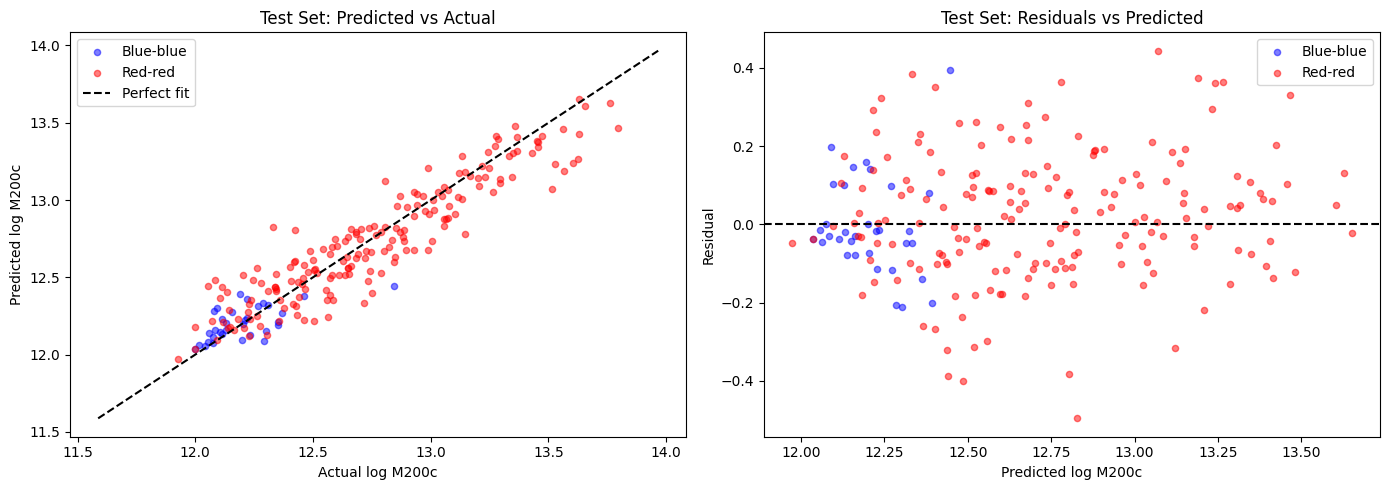

=== Train Set ===
R²:   0.883
RMSE: 0.144 dex

=== Test Set (unseen) ===
R²:   0.871
RMSE: 0.161 dex

Blue-blue R²: 0.403
Red-red R²:   0.849

=== Overfitting Check ===
Train R²: 0.883
Test R²:  0.871
Gap:      0.012  (should be < 0.05)


In [21]:
y_pred_train = fit_2.stan_variable('y_rep_train').mean(axis=0)
y_pred_test  = fit_2.stan_variable('y_rep_test').mean(axis=0)
residuals_test = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test[g_test==1], y_pred_test[g_test==1], alpha=0.5, color='blue', label='Blue-blue', s=20)
ax.scatter(y_test[g_test==2], y_pred_test[g_test==2], alpha=0.5, color='red',  label='Red-red',   s=20)
lims = [log_m200c.min()-0.1, log_m200c.max()+0.1]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual log M200c'); ax.set_ylabel('Predicted log M200c')
ax.set_title('Test Set: Predicted vs Actual'); ax.legend()

ax = axes[1]
ax.scatter(y_pred_test[g_test==1], residuals_test[g_test==1], alpha=0.5, color='blue', label='Blue-blue', s=20)
ax.scatter(y_pred_test[g_test==2], residuals_test[g_test==2], alpha=0.5, color='red',  label='Red-red',   s=20)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted log M200c'); ax.set_ylabel('Residual')
ax.set_title('Test Set: Residuals vs Predicted'); ax.legend()

plt.tight_layout(); plt.show()

train_r2 = r2_score(y_train, y_pred_train)
test_r2  = r2_score(y_test,  y_pred_test)
print('=== Train Set ===')
print(f"R²:   {train_r2:.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f} dex")
print('\n=== Test Set (unseen) ===')
print(f"R²:   {test_r2:.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f} dex")
print(f"\nBlue-blue R²: {r2_score(y_test[g_test==1], y_pred_test[g_test==1]):.3f}")
print(f"Red-red R²:   {r2_score(y_test[g_test==2], y_pred_test[g_test==2]):.3f}")
print('\n=== Overfitting Check ===')
print(f"Train R²: {train_r2:.3f}")
print(f"Test R²:  {test_r2:.3f}")
print(f"Gap:      {train_r2 - test_r2:.3f}  (should be < 0.05)")